
# Model Optimization

## Objective:
In this module, we will demonstrate how regularization helps mitigate overfitting. We will explore both L1 and L2 regularization techniques and analyze their impact on model performance. Additionally, we will study the role of gradient descent optimization and investigate how learning rates affect model training and convergence.

<center><img src="https://media.licdn.com/dms/image/v2/C5612AQF-Nn-juDj6aQ/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1520148281966?e=2147483647&v=beta&t=29vrA455dv5JmHx2GkT1h7R3JWIdd_4hF2DAyXrOGKM" width=500 height=300 /></center>

- 1. Data Preparation and Preprocessing:
    Perform data cleaning by handling missing values, scaling numerical features, and encoding categorical variables.
    Split the dataset into training and validation sets for robust model evaluation.

- 2. Gradient Descent Convergence:
    Evaluate the impact of different learning rates on the convergence of the gradient descent algorithm by running training with various rate settings.

- 3. Model Training:
    Train baseline models such as Linear Regression or Logistic Regression to establish a performance benchmark.
    Use advanced models like LightGBM or Random Forest for improved performance.

- 4. Hyperparameter Tuning:
    Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV to find the optimal regularization strength (e.g., alpha or lambda).
    Evaluate the impact of regularization on model performance using metrics such as accuracy, RMSE, or F1-score.

- 5. Regularization Techniques:
    Apply L1 regularization (Lasso) to encourage sparsity in the model by reducing insignificant feature weights to zero.
    Use L2 regularization (Ridge) to penalize large coefficients and improve generalization.
    Combine L1 and L2 regularization (Elastic Net) for a balanced effect.

##1. Introduction

L1 and L2 regularization are essential techniques in machine learning used to prevent overfitting and enhance model generalization. Regularization adds a penalty to the loss function based on the magnitude of model coefficients, encouraging simpler and more robust models. However, before applying regularization, understanding the optimization process, particularly gradient descent, is critical to ensure effective training.

- Gradient Descent and Learning Rates: The gradient descent algorithm is widely used for optimizing the loss function. Learning rates determine the step size during parameter updates. Setting an appropriate learning rate is crucial—too high may lead to divergence, while too low results in slow convergence. Evaluating the effects of different learning rates helps optimize the training process, ensuring better performance before regularization techniques are introduced.

- L1 Regularization (Lasso): This technique applies an absolute value penalty to the coefficients, driving some of them to zero, effectively performing feature selection.

- L2 Regularization (Ridge): This method uses a squared penalty, which discourages large coefficients but does not zero them out, promoting smaller but non-zero weights.

Regularization techniques are widely used in applications requiring interpretable models, efficient feature selection, or the ability to handle multicollinearity.

<center><img src="https://www.statology.org/wp-content/uploads/2024/05/awan_5_regularization_techniques-4.png" width=800 height=300 /></center>

By controlling model complexity, L1 and L2 regularization improve predictive performance and ensure the model generalizes well to unseen data, making them indispensable in modern machine learning workflows.



##2. Steps involved

- **Data Collection**

    a. Gathering Data:
    The dataset used for this notebook is this <a href='https://www.kaggle.com/datasets/yasserh/housing-prices-dataset'>link</a>.

    b. Target Variable Identification:
    Identify the target variable to be predicted and ensure it is a continuous numerical variable.

- **Data Preprocessing**

    a. Handling Missing Values:
    Address missing data through techniques such as imputation or removing rows/columns based on the extent of missingness.

    b. Categorical Encoding:
    Convert categorical variables into numerical representations using methods like one-hot encoding or label encoding.

- **Exploratory Data Analysis (EDA)**

    a. The structured EDA process provides critical insights into the dataset's structure, relationships, and potential issues, setting a strong foundation for subsequent model building and analysis.

- **Gradient Descent Convergence**

    a. After processing the data, we will train the gradient descent model to analyze how varying learning rates influence the model's training process and its convergence behavior.

- **Model Training & Optimization**

    a. Hyperparameter Tuning:
    Perform fine-tuning using GridSearchCV or RandomizedSearchCV to optimize parameters

    b. Regularization Techniques:
    Apply L1 Regularization (Lasso) to encourage sparsity by reducing coefficients of less important features to zero.
    Apply L2 Regularization (Ridge) to prevent overfitting by discouraging large coefficient values.
    Combine L1 and L2 regularization (Elastic Net) for balanced optimization.

# 2. Steps involved

In [1]:
# Core Libraries
import numpy as np  # For numerical computations
import pandas as pd  # For data manipulation and analysis

# Data Preprocessing and Transformation
from sklearn.preprocessing import OneHotEncoder  # For encoding categorical variables
from sklearn.preprocessing import PolynomialFeatures  # For creating polynomial features
from sklearn.preprocessing import MinMaxScaler  # For scaling feature values

# Data Visualization
import matplotlib.pyplot as plt  # For plotting graphs
import seaborn as sns  # For advanced and aesthetic data visualization

# Statistical Analysis
from statsmodels.stats.outliers_influence import variance_inflation_factor  # For calculating VIF (multicollinearity check)

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # Regression models
import xgboost as xgb  # XGBoost model

# Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score  # Metrics to evaluate regression models

# Model Selection and Hyperparameter Tuning
from sklearn.model_selection import train_test_split  # For splitting data into train and test sets
from sklearn.model_selection import GridSearchCV  # For hyperparameter tuning using grid search


# 2.1 Data Collection

## 2.1.1 Gathering Data<br>
 The data is downloded from <a href='https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download'>link</a>

 A simple yet challenging project, to predict the housing price based on certain factors like house area, bedrooms, furnished, nearness to mainroad, etc.

In [2]:
#Load data from the csv file
housing_data = pd.read_csv('Housing.csv')

In [3]:
# Display the first few rows of the housing dataset to get an overview
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# Display a concise summary of the housing dataset
housing_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


##Observation

There are no null values in the data.

In [5]:
# Separate categorical and numerical features
categorical_features = housing_data.select_dtypes(include=['object']).columns
numerical_features = housing_data.select_dtypes(include=['number']).columns

In [6]:
housing_data[numerical_features].describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
housing_data[categorical_features].describe()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,furnishingstatus
count,545,545,545,545,545,545,545
unique,2,2,2,2,2,2,3
top,yes,no,no,no,no,no,semi-furnished
freq,468,448,354,520,373,417,227


## 2.1.2 Target Variable Identification<br>

 Here we are trying to predict the price of the house based on the attributes like area, bedrooms, location etc. So here we will take price as our target variable.

# 2.2 Data Preprocessing

## 2.2.1 Handling Missing Values<br>

 There are no null values in the data. So we don't need to do any processing here

## 2.2.2 Categorical Encoding<br>

 is a technique used to transform categorical data into a format that can be provided to machine learning models, which generally require numerical input.

In [8]:
# Create a OneHotEncoder object
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features
for col in categorical_features:
  housing_data[col] = encoder.fit_transform(housing_data[[col]])

In [9]:
housing_data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,0.0,1.0,1.0,1.0,0.0,2,0.0,1.0
1,12250000,8960,4,4,4,0.0,1.0,1.0,1.0,0.0,3,1.0,1.0
2,12250000,9960,3,2,2,0.0,1.0,0.0,1.0,1.0,2,0.0,0.0
3,12215000,7500,4,2,2,0.0,1.0,0.0,1.0,0.0,3,0.0,1.0
4,11410000,7420,4,1,2,0.0,0.0,0.0,1.0,0.0,2,1.0,1.0


# 2.3 Exploratory Data Analysis (EDA)
It is a critical step in the data science process where you analyze and summarize datasets to uncover patterns, detect anomalies, test hypotheses, and check assumptions. It helps in understanding the data's structure, distributions, and relationships before applying any machine learning model or statistical technique.

C:\Users\Rajeev\AppData\Local\Temp\ipykernel_90396\4200653101.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(housing_data.price)


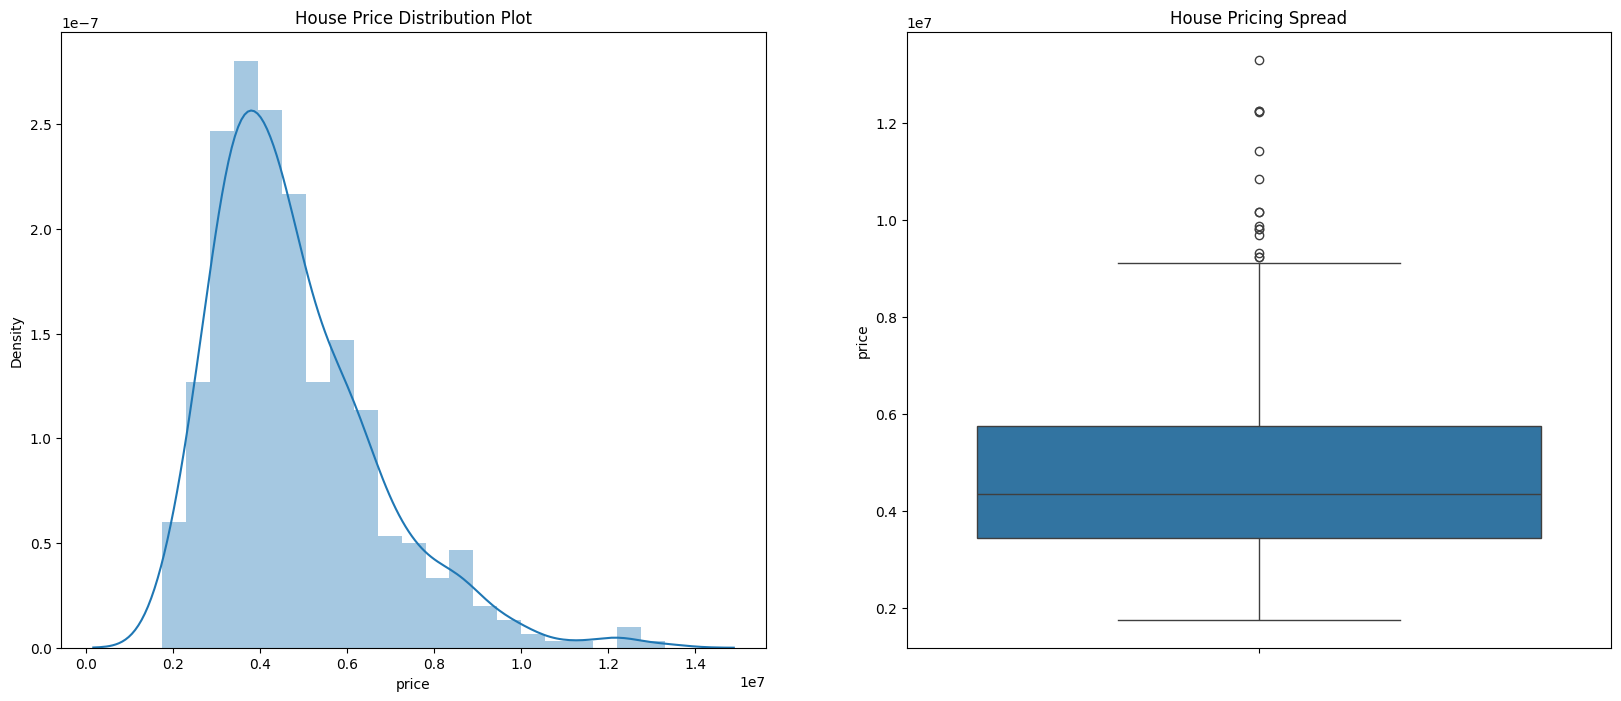

In [10]:
# Understanding the target variable
plt.figure(figsize=(20,8))

plt.subplot(1,2,1)
plt.title('House Price Distribution Plot')
sns.distplot(housing_data.price)

plt.subplot(1,2,2)
sns.boxplot(housing_data.price)
plt.title('House Pricing Spread')

plt.show()

**Inference:** The plot seemed to be right-skewed mildly. There is a slight difference between the mean and the median of the price distribution.

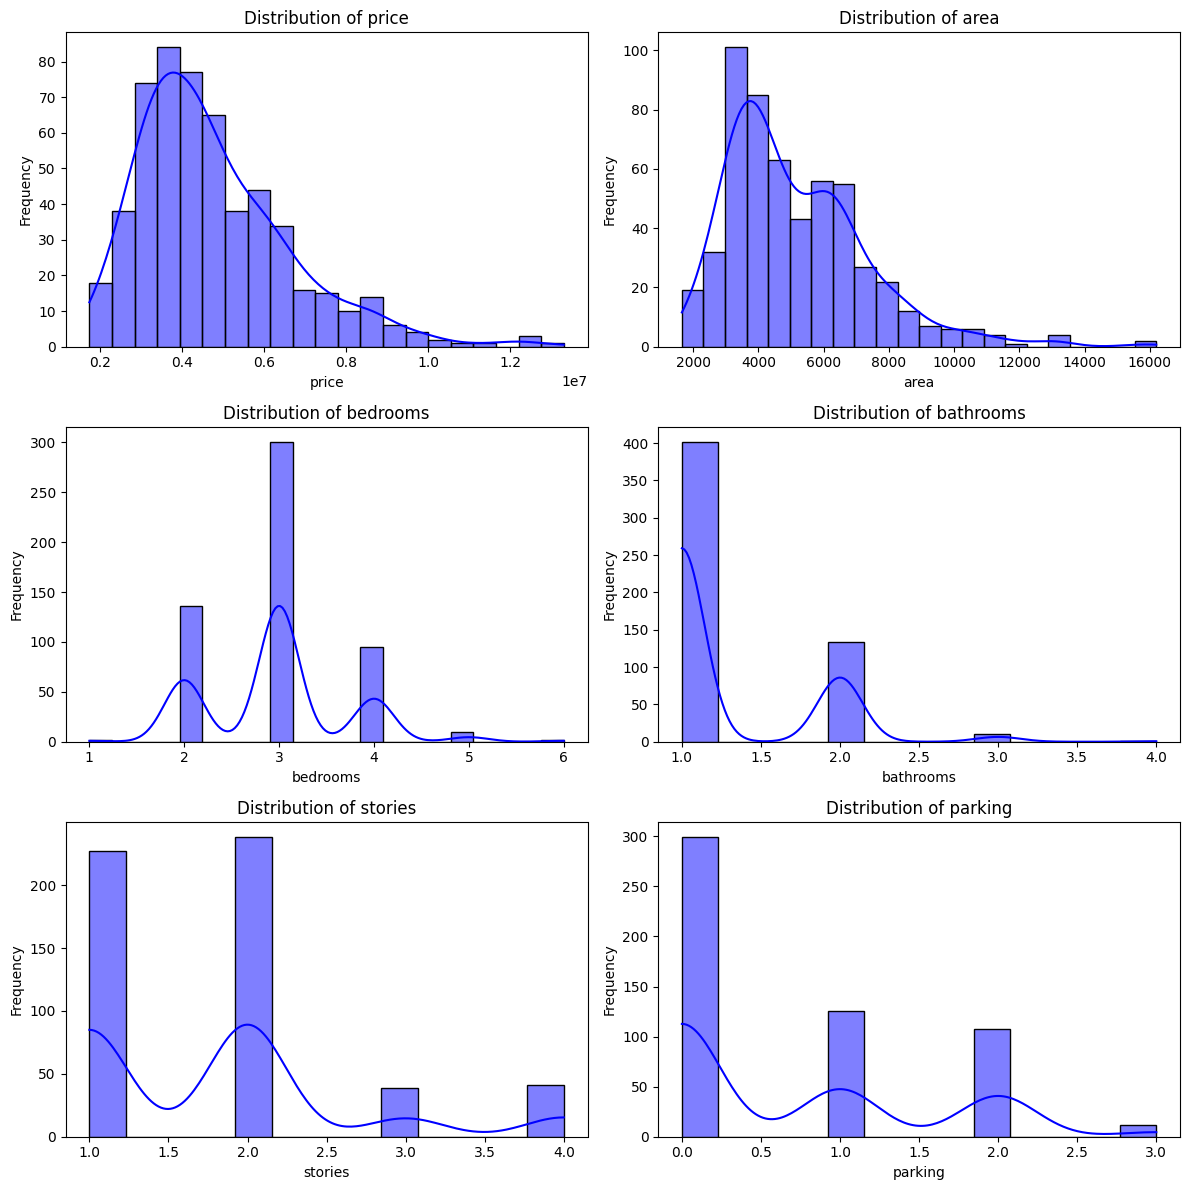

In [11]:
# Understanding the numerical features
# Create a grid of 3x2
fig, axes = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns
axes = axes.flatten()  # Flatten to easily iterate over

# Plot distributions
for i, col in enumerate(numerical_features):
    sns.histplot(housing_data[col], kde=True, ax=axes[i], color='blue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Adjust layout
plt.tight_layout()
plt.show()

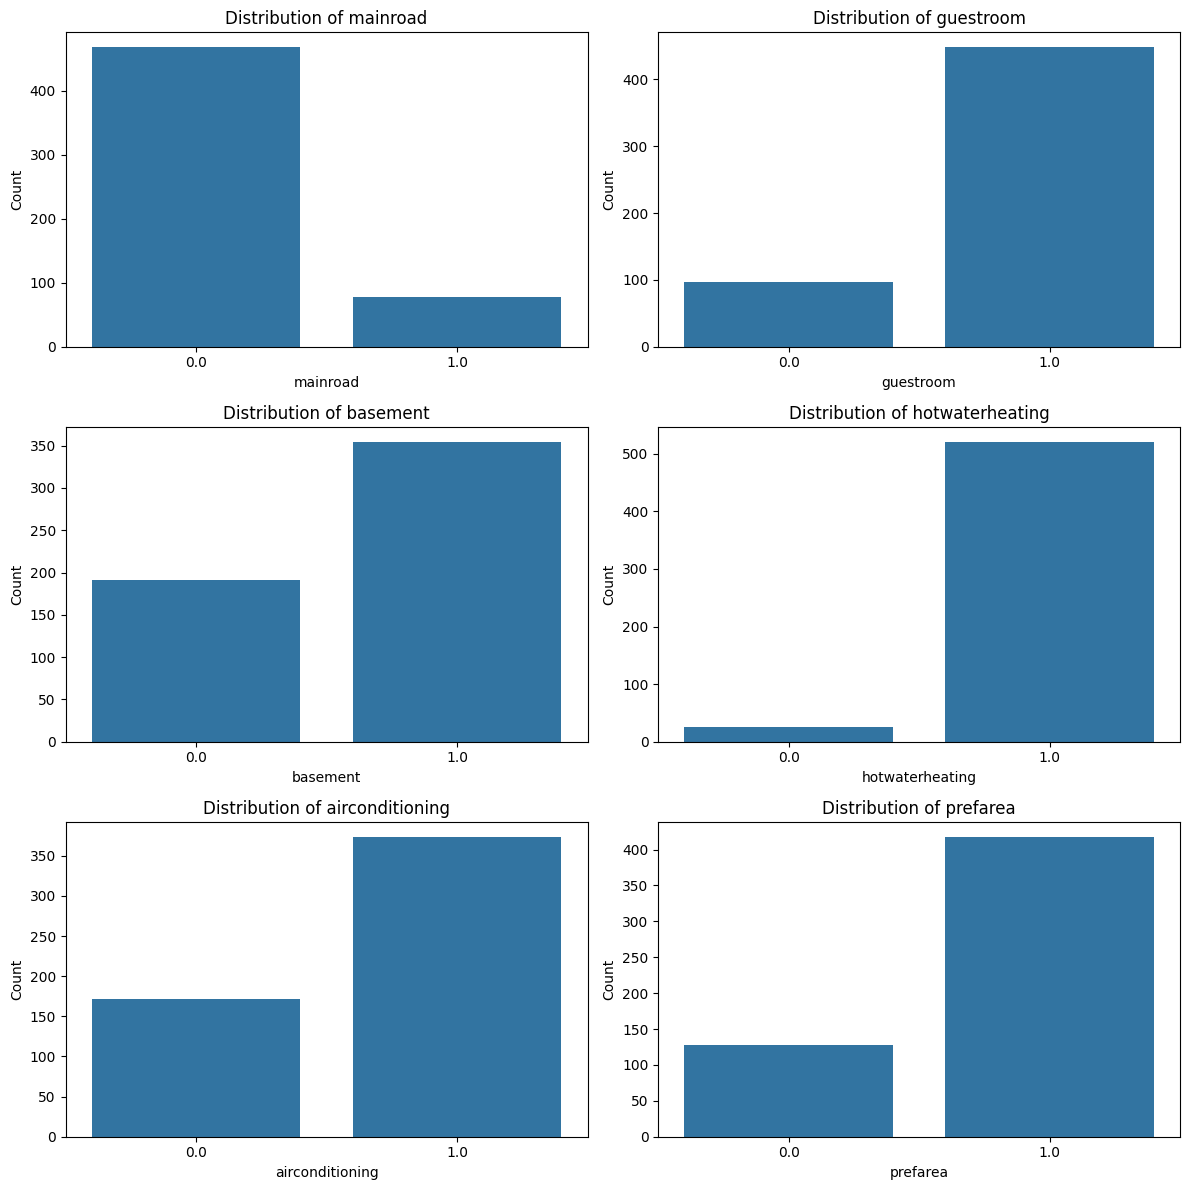

In [12]:
# Understanding the categorical features
# Plot 3x2 grid
categorical_cols = categorical_features[:-1]
fig, axes = plt.subplots(3, 2, figsize=(12, 12))  # 3 rows, 2 columns grid

# Flatten axes for easy iteration
axes = axes.flatten()

# Plot each categorical column
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=housing_data, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Clipping outliers

From EDA, it can be observed that the outliers are present in the data. To prevent them from adversely affecting the performance of the regression model, we will clip these outliers.

Clipping outliers is a technique where extreme values (outliers) in a dataset are capped or trimmed to a specified threshold. This process prevents outliers from disproportionately influencing the model's performance.

<center><img src="https://miro.medium.com/v2/resize:fit:1400/1*1LizDb-8MxYMUyRlUVOXmw.png" width=500/></center>

In [13]:
# Splitting into 'features' and 'target'
features = list(numerical_features[1:]) + list(categorical_features)
target = 'price'

In [14]:
X, y = housing_data[features], housing_data[target]

In [26]:
# Function to clip using percentiles
def clip_using_percentiles(y, lower_percentile=1, upper_percentile=99):
    """
    Clip the target variable based on the lower and upper percentiles.

    Parameters:
    - y: Target variable (array-like).
    - lower_percentile: The lower percentile to clip (default: 1st percentile).
    - upper_percentile: The upper percentile to clip (default: 99th percentile).

    Returns:
    - y_clipped: The clipped target variable.
    """
    lower_limit = np.percentile(y, lower_percentile)
    upper_limit = np.percentile(y, upper_percentile)

    # Clip the target variable
    y_clipped = np.clip(y, lower_limit, upper_limit)
    print(y_clipped)
    return y_clipped

In [27]:
# Clip the target variable using percentiles
y = clip_using_percentiles(y, lower_percentile=0, upper_percentile=95)
print(y)

0      8400000
1      8400000
2      8400000
3      8400000
4      8400000
        ...   
540    1820000
541    1767150
542    1750000
543    1750000
544    1750000
Name: price, Length: 545, dtype: int64
0      8400000
1      8400000
2      8400000
3      8400000
4      8400000
        ...   
540    1820000
541    1767150
542    1750000
543    1750000
544    1750000
Name: price, Length: 545, dtype: int64


## Plot correlation matrix

A correlation matrix is a table that shows the correlation coefficients between many variables. Each cell in the table represents the correlation between two variables. This matrix helps to understand the relationships between different features in the dataset.



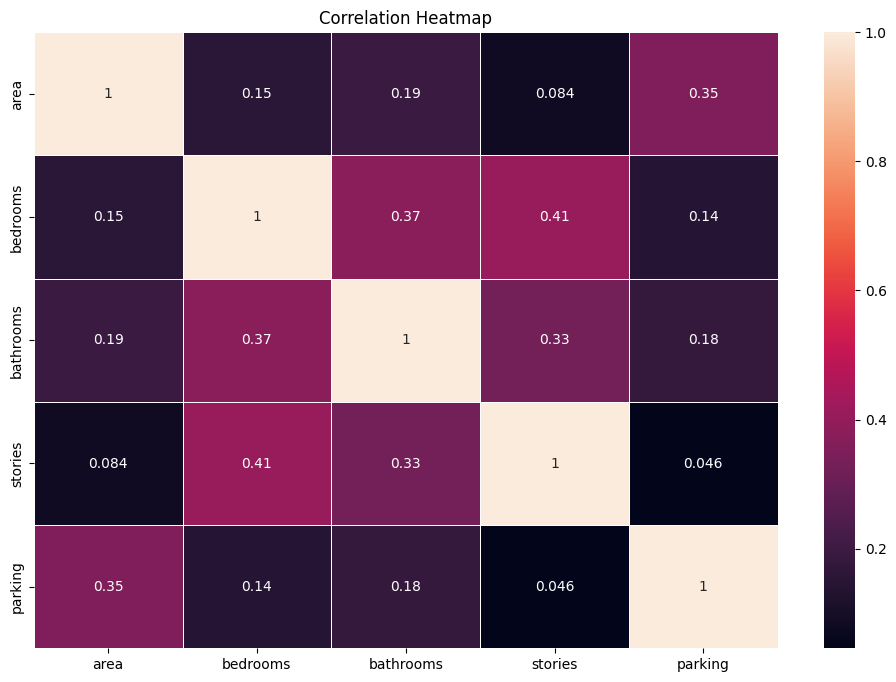

In [17]:
# Plotting a heat map
cor_matrix= housing_data[numerical_features[1:]].corr()
plt.figure(figsize=(12, 8))  # Set the figure size
sns.heatmap(cor_matrix, annot=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Interpretation
- The highest correlation is between bedrooms and stories, indicating that houses with more bedrooms might slightly tend to have more stories.
- The lowest non-diagonal correlation is between stories and parking, showing no significant relationship.
- In general, the correlations in this matrix are weak to moderate, suggesting limited linear relationships among the variables.


# 2.4 Gradient Descent Convergence

Before diving into model training and regularization, it’s important to understand the impact of learning rates on model convergence. A low learning rate results in slow learning, causing the model to take longer to converge. Conversely, a high learning rate can lead to overshooting the optimal solution, causing instability. Therefore, identifying the most optimal learning rate is crucial for efficient and accurate convergence.

In [18]:
def gradient_descent_linear(X, y, learning_rates, iterations):

    """
    Perform gradient descent for linear regression with multiple learning rates and return the loss history and R2 scores.

    Parameters:
        X (numpy.ndarray or pandas.DataFrame): Feature matrix of shape (m, n), where m is the number of samples
                                               and n is the number of features.
        y (numpy.ndarray or pandas.Series): Target vector of shape (m, 1).
        learning_rates (list): A list of learning rates to evaluate.
        iterations (int): Number of iterations to run gradient descent.

    Returns:
        results (dict): A dictionary where keys are learning rates and values are lists of loss values (MSE)
                        at each iteration for that learning rate.
        r2_scores (dict): A dictionary where keys are learning rates and values are the final R2 scores
                          after gradient descent.

    """

    results = {}
    r2_scores = {}

    m, n = X.shape
    X = np.c_[np.ones(m), X]  # Add intercept term
    y = y.values.reshape(-1, 1)  # Ensure y is a column vector

    for lr in learning_rates:
        theta = np.zeros((n + 1, 1))  # Initialize parameters (n+1 for intercept)
        history = []  # To store loss values

        for _ in range(iterations):
            # Compute predictions
            predictions = np.dot(X, theta)
            # Compute gradient
            gradient = (1 / m) * np.dot(X.T, (predictions - y))
            # Update parameters
            theta -= lr * gradient
            # Compute and store loss (MSE)
            loss = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
            history.append(loss)

        results[lr] = history
        r2_scores[lr] = round(r2_score(y, predictions), 2)

    return results, r2_scores


def plot_loss_convergence(results, iterations):

    """
    Visualize the loss convergence for different learning rates during gradient descent.

    Parameters:
        results (dict): A dictionary where keys are learning rates and values are lists of loss values (MSE)
                        at each iteration for that learning rate.
        iterations (int): Number of iterations to display on the x-axis.

    Returns:
        None
    """

    plt.figure(figsize=(12, 8))
    for lr, history in results.items():
        plt.plot(range(iterations), history, label=f"LR: {lr}")

    plt.xlabel("Iterations")
    plt.ylabel("Loss (MSE)")
    plt.title("Loss Convergence for Different Learning Rates")
    plt.legend()
    plt.grid()
    plt.show()

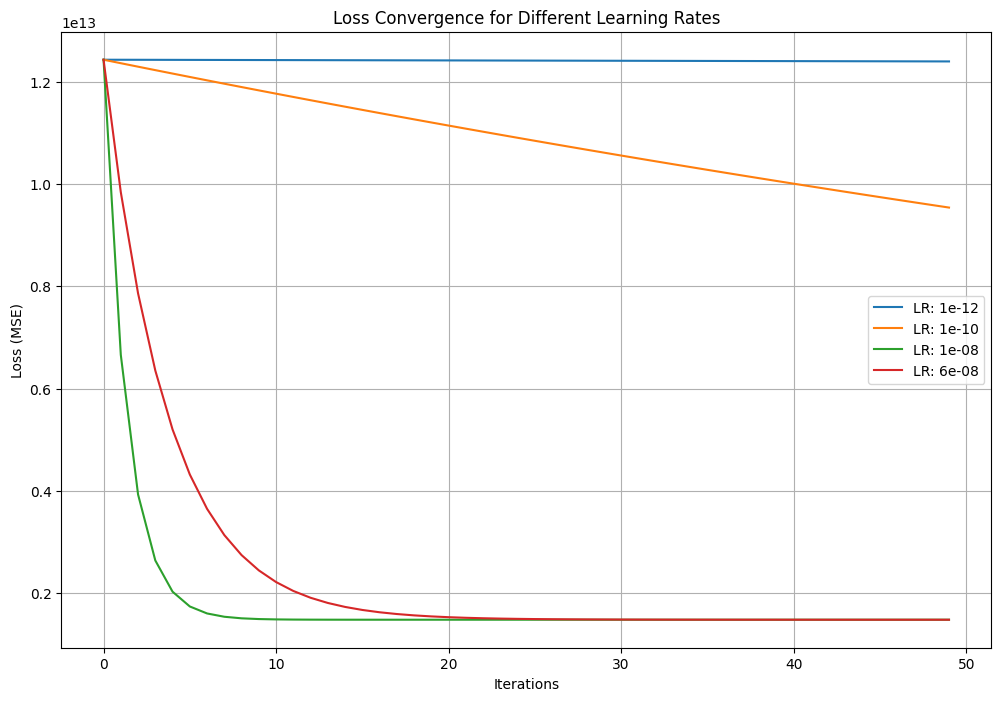


 R2 scores for different learning rates: {1e-12: -7.87, 1e-10: -5.82, 1e-08: -0.06, 6e-08: -0.06}


In [28]:
# Parameters
learning_rates = [1e-12, 1e-10, 1e-8, 6e-8]  # Learning rates to compare
iterations = 50  # Number of iterations

# Run Gradient Descent and Plot Results
results, r2_scores = gradient_descent_linear(X, y, learning_rates, iterations)
plot_loss_convergence(results, iterations)

print(f'\n R2 scores for different learning rates: {r2_scores}')

## Interpretation

The graph depicts the convergence of loss (MSE) over iterations for different learning rates (LR). Here’s an interpretation:

- **Very Low Learning Rates (1e-12, 1e-10):**

  - The lines representing these learning rates (blue and orange) show extremely slow convergence.
  - The loss decreases very gradually, indicating that the model is learning too slowly to make significant progress within the given number of iterations.

- **Moderate Learning Rate (1e-08):**

  - The green line demonstrates a good balance between stability and speed. -
  - The loss reduces quickly and converges smoothly to a minimum, making it an optimal choice for this scenario.

- **Relatively High Learning Rate (6e-08):**

  - The red line shows faster initial convergence than 1e-08, but it fluctuates slightly and takes longer to stabilize.
  - This indicates that while the learning rate is higher, it might risk overshooting or introducing instability.

**Key Insights:**
- Extremely low learning rates result in slow convergence and inefficient training.
- A moderate learning rate (1e-08 in this case) ensures fast and stable convergence.
- Higher learning rates can accelerate learning but may cause oscillations or instability, as seen with 6e-08.

**Recommendations:**
- Use a learning rate like 1e-08 for efficient and stable convergence.
- Avoid excessively low or high learning rates to prevent slow training or unstable behavior.

**Next Step:**
- Based on the R2 score of the recommended learning rate, it appears that we could explore a more complex model to better capture the relationships between the features and the target.

#2.5 Model Training & Optimization

A process of building and refining machine learning models to make accurate predictions or classifications.

<center><img src="https://miro.medium.com/v2/resize:fit:1400/1*TFY4OWhJoXLiBTYs1rq9EQ.jpeg" width=500/></center>

### 2.5.1 XGBoost Regressor Model
XGBoost is chosen for housing data regression due to its efficiency, ability to handle non-linear relationships, and strong performance with tabular datasets.

In [20]:
def train_xgboost_regression(X, y, test_size=0.2, alpha=0.0, lambda_=0.0,
                             max_depth=3, eta=0.1, num_boost_round=5,
                             subsample=0.5, colsample_bytree=0.5,
                             random_state=42):
    """
    Trains an XGBoost regression model.

    Parameters:
    - X: pandas DataFrame or numpy array of features.
    - y: pandas Series or numpy array of target values.
    - test_size: Proportion of the dataset to include in the test split.
    - alpha: L1 regularization strength (default: 0.0).
    - lambda_: L2 regularization strength (default: 0.0).
    - max_depth: Maximum depth of the trees (default: 3).
    - eta: Learning rate (default: 0.1).
    - num_boost_round: Number of boosting iterations (default: 100).
    - random_state: Seed for reproducibility (default: 42).

    Returns:
    - model: Trained XGBoost model.
    - metrics: Dictionary containing training and test mean squared errors.
    """
    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                        random_state=random_state)

    # Convert data to XGBoost DMatrix format
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dtest = xgb.DMatrix(X_test, label=y_test)

    # Define XGBoost parameters
    params = {
        'objective': 'reg:squarederror',
        'alpha': alpha,        # L1 regularization
        'lambda': lambda_,     # L2 regularization
        'max_depth': max_depth,
        'eta': eta,             # Learning rate
        'subsample': subsample,
        'colsample_bytree': colsample_bytree
    }

    # Train the model
    model = xgb.train(params, dtrain, num_boost_round=num_boost_round)

    # Predict on the train and test sets
    y_train_pred = model.predict(dtrain)
    y_test_pred = model.predict(dtest)

    # Calculate R2 Score (MSE)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    metrics = {
        'r2_train': r2_train,
        'r2_test': r2_test
    }

    # Print metrics
    print(f"R2 train score: {r2_train:.2f}")
    print(f"R2 test score: {r2_test:.2f}")

    #return model, metrics

## Note:

For xg boost model parameter alpha:
- alpha: L1 regularization strength.
- lambda_: L2 regularization strength.

These parameters can be treated as hyperparameters and optimized by performing a grid search with different values to identify the best configuration for the model.

## Train xgboost regressor model

In [21]:
train_xgboost_regression(X, y)

R2 train score: 0.35
R2 test score: 0.29


## Interpretation:
On looking at the R2 score it seems that both scores are relatively low (closer to 0 than 1), which indicates the model is not explaining a significant portion of the variance in the target variable. There might be room for improvement in feature engineering, hyperparameter tuning, or data preprocessing.


## 2.5.2 Hyperparameter Tuning of XGBoost Model

 The process of finding the optimal set of hyperparameters for a machine learning model to improve its performance. Hyperparameters are the configurations set before training that control how the learning algorithm works.

In [22]:
from xgboost import XGBRegressor

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)
# 1. Initialize the XGBoost regressor
model = XGBRegressor(objective='reg:squarederror', random_state=42)

# 2. Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# 3. Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,  # 3-fold cross-validation
    scoring='r2',  # Use R² as the evaluation metric
    verbose=1,
    n_jobs=-1  # Use all available processors
)

# 4. Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# 5. Get the best hyperparameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best R² Score on Training Data:", grid_search.best_score_)

# 6. Evaluate the best model on the test data
best_model = grid_search.best_estimator_
test_r2 = best_model.score(X_test, y_test)
print("R² Score on Test Data:", test_r2)

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500, 'subsample': 0.7}
Best R² Score on Training Data: 0.6568071382304675
R² Score on Test Data: 0.663169225619429


In [23]:
train_xgboost_regression(X, y, max_depth=5, eta=0.01, num_boost_round=500,
                             subsample=0.7, colsample_bytree=0.7)

R2 train score: 0.91
R2 test score: 0.66


## Interpretation

While the model performs well after hyperparamater tuning but huge difference between r2 score of training and test samples indicates that the model is overfitting. We can consider regularization techniques to close the gap between training and test performance.

## 2.5.3 Regularization Techniques

- **L1 Regularization :**
Adds a penalty proportional to the absolute value of weights (∣𝑤∣) to the loss function. It encourages sparsity by shrinking some weights to exactly zero, making it useful for feature selection.

- **L2 Regularization :**
Adds a penalty proportional to the square of weights (𝑤2) to the loss function. It discourages large weights, stabilizing the model but retaining all features with smaller contributions.



In [24]:
train_xgboost_regression(X, y, alpha=5, lambda_=15,
                             max_depth=5, eta=0.01, num_boost_round=500,
                             subsample=0.7, colsample_bytree=0.7)

R2 train score: 0.80
R2 test score: 0.65


## Interpretation

The regularization has succeeded in reducing overfitting, as evidenced by the narrower train-test R² gap. The model is now more robust and better at generalizing to unseen data.